# Credit Risk Segmentation using K-means

## Objective

This project applies unsupervised machine learning to segment borrowers based on credit behaviour using Lending Club loan data.

The objective is to identify meaningful borrower groups that can support credit risk analysis, portfolio monitoring, and risk-based decision-making.

## Importing libraries

In [4]:
# Libraries
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
# Optimising output settings

pd.set_option('display.float_format', '{:.2f}'.format)

## Loading and understanding the dataset

The Lending Club dataset, downloaded from Kaggle, is available as a CSV file and contains loan-level information, including borrower credit profile, loan status, repayment behaviour, and credit history.

In [6]:
# Loading the dataset
os.chdir("D:\Salini\Professional Development\Projects\Lending Club\Loan Data")
credit_data = pd.read_csv("Credit Dataset.csv")

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Hp\AppData\Local\Temp\ipykernel_5112\3424854548.py:2: SyntaxWarning: invalid escape sequence '\S'
  os.chdir("D:\Salini\Professional Development\Projects\Lending Club\Loan Data")


C:\Users\Hp\AppData\Local\Temp\ipykernel_5112\3424854548.py:3: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  credit_data = pd.read_csv("Credit Dataset.csv")


In [7]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [8]:
print("Dataset shape:", credit_data.shape)

Dataset shape: (2260701, 151)


The dataset contains ~2.2 M rows and over 150 columns that represent features of each loan.

In [9]:
credit_data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.00,35000.00,35000.00,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.00,10400.00,10400.00,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Feature Selection

The dataset contains more than 150 loan-level features. It is important to identify features that provide relevant information withofor risk based segmentation.

The selected features are based on credit risk relevance:

- `dti`: Debt-to-income ratio
- `revol_util`: Credit utilisation
- `delinq_2yrs`: Number of delinquencies in the past 2 years
- `inq_last_6mths`: Recent credit inquiries, used as a proxy for credit hunger
- `emp_length`: Employment length
- `fico_range_low` and `fico_range_high`: Used to calculate average FICO score

These variables capture borrower leverage, repayment behaviour, credit activity, employment stability, and creditworthiness.

In [10]:
# Filtering relevant columns from dataset
credit_data_selected = credit_data[['id','fico_range_high','fico_range_low','inq_last_6mths','revol_util','dti','delinq_2yrs','loan_status','emp_length']].copy()
# Feature Engineering
credit_data_selected.rename(columns={'revol_util': 'credit_utilization','inq_last_6mths': 'credit_hunger'}, inplace=True)
credit_data_selected["avg_fico"] = (credit_data_selected["fico_range_high"] + credit_data_selected["fico_range_low"])/2


## Data Cleaning

The data cleaning process includes:

- Converting employment length into numerical values
- Simplifying loan status into broader categories
- Treating invalid values
- Handling missing values

In [11]:
# Helper Functions

def convert_emp_length(x):
    if pd.isna(x):
        return np.nan
    elif x == "< 1 year":
        return 0.5
    elif x == "10+ years":
        return 10
    else:
        return int(x.split()[0])


def simplify_status(x):
    if pd.isna(x):
        return "Unknown"
    if "Fully Paid" in x:
        return "Good"
    elif "Charged Off" in x or x == "Default":
        return "Bad"
    elif "Late" in x or "Grace" in x:
        return "Delinquent"
    else:
        return "Ongoing"

In [12]:
# Cleaning employment length

print(credit_data_selected['emp_length'].unique())
credit_data_selected.loc[:,"emp_length"] = credit_data_selected["emp_length"].apply(convert_emp_length)
credit_data_selected["emp_length"] = pd.to_numeric(credit_data_selected["emp_length"],errors='coerce')


['10+ years' '3 years' '4 years' '6 years' '1 year' '7 years' '8 years'
 '5 years' '2 years' '9 years' '< 1 year' nan]


In [13]:
# Cleaning loan status 

print(credit_data_selected['loan_status'].unique())

credit_data_selected.loc[:,"loan_status"] = credit_data_selected["loan_status"].apply(simplify_status)
credit_data_selected = credit_data_selected[credit_data_selected["loan_status"] != "Unknown"]


['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default' nan
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']


In [14]:
# Treating invalid values

credit_data_selected.loc[(credit_data_selected['dti'] < 0) | (credit_data_selected['dti'] > 100),'dti'] = np.nan
credit_data_selected.loc[credit_data_selected['credit_utilization'] > 100, 'credit_utilization'] = np.nan


In [15]:
# Identifying missing values

credit_data_selected.isna().sum()

id                         0
fico_range_high            0
fico_range_low             0
credit_hunger             30
credit_utilization      9145
dti                     4274
delinq_2yrs               29
loan_status                0
emp_length            146907
avg_fico                   0
dtype: int64

In [16]:
# Handling missing values

credit_data_selected.dropna(subset=['dti','delinq_2yrs','loan_status','credit_utilization','credit_hunger','avg_fico'], inplace = True)
credit_data_selected.loc[:, "emp_length"] = credit_data_selected["emp_length"].fillna(credit_data_selected["emp_length"].median())

credit_data_selected.isna().sum()

id                    0
fico_range_high       0
fico_range_low        0
credit_hunger         0
credit_utilization    0
dti                   0
delinq_2yrs           0
loan_status           0
emp_length            0
avg_fico              0
dtype: int64

The approach taken for handling missing values is to drop them when they are < 5% of the total data and impute them when they are > 5% of the total data. Here, only missing values for employment length were > 5%, and these values were imputed with the median employment length. The remaining missing values were dropped.

## Exploratory Data Analysis

Exploratory analysis helps understand feature distributions, skewness, and outliers before clustering.

In [17]:
# Selected features
features = ['dti','credit_utilization','delinq_2yrs','emp_length','credit_hunger','avg_fico']

credit_data_selected.describe()

,fico_range_high,fico_range_low,credit_hunger,credit_utilization,dti,delinq_2yrs,emp_length,avg_fico
count,2247268.00,2247268.00,2247268.00,2247268.00,2247268.00,2247268.00,2247268.00,2247268.00
mean,702.62,698.62,0.58,50.16,18.57,0.31,5.98,700.62
std,33.02,33.02,0.89,24.56,9.30,0.87,3.53,33.02
min,614.00,610.00,0.00,0.00,0.00,0.00,0.50,612.00
25%,679.00,675.00,0.00,31.50,11.89,0.00,3.00,677.00
50%,694.00,690.00,0.00,50.10,17.83,0.00,6.00,692.00
75%,719.00,715.00,1.00,69.10,24.46,0.00,10.00,717.00
max,850.00,845.00,33.00,100.00,100.00,58.00,10.00,847.50


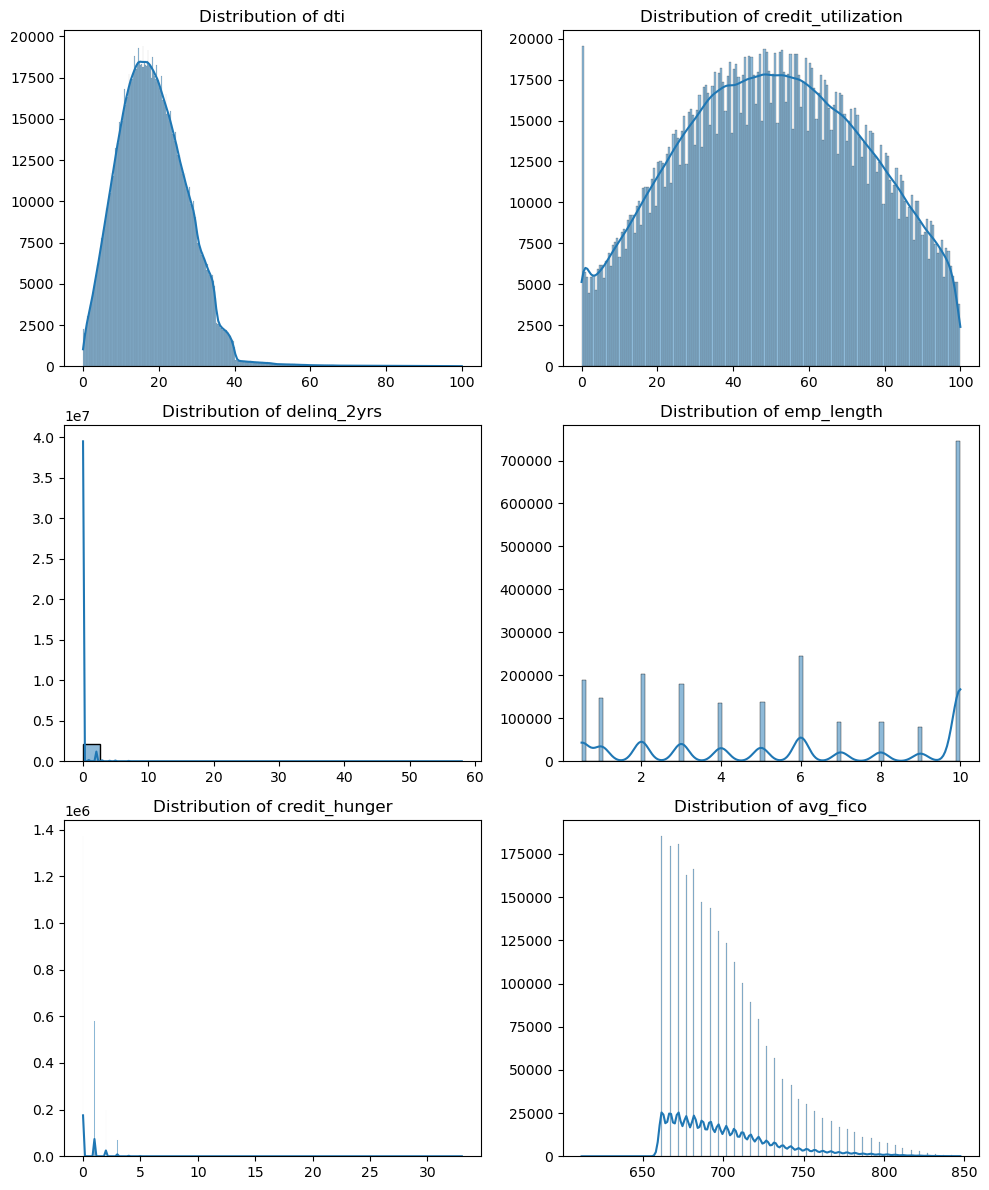

In [18]:
# Distribution Plots
n_cols = 2 
n_rows = math.ceil(len(features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(credit_data_selected[col],kde=True,bins='auto',ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### Distribution Insights

- `delinq_2yrs` and `credit_hunger` are highly skewed.
- `credit_utilization` is widely distributed across borrowers.
- `avg_fico` provides a strong creditworthiness signal.
- `emp_length` is discrete, which is expected because it represents employment years.

dti : 19052
credit_utilization : 0


delinq_2yrs : 419250
emp_length : 0


credit_hunger : 94069
avg_fico : 74529


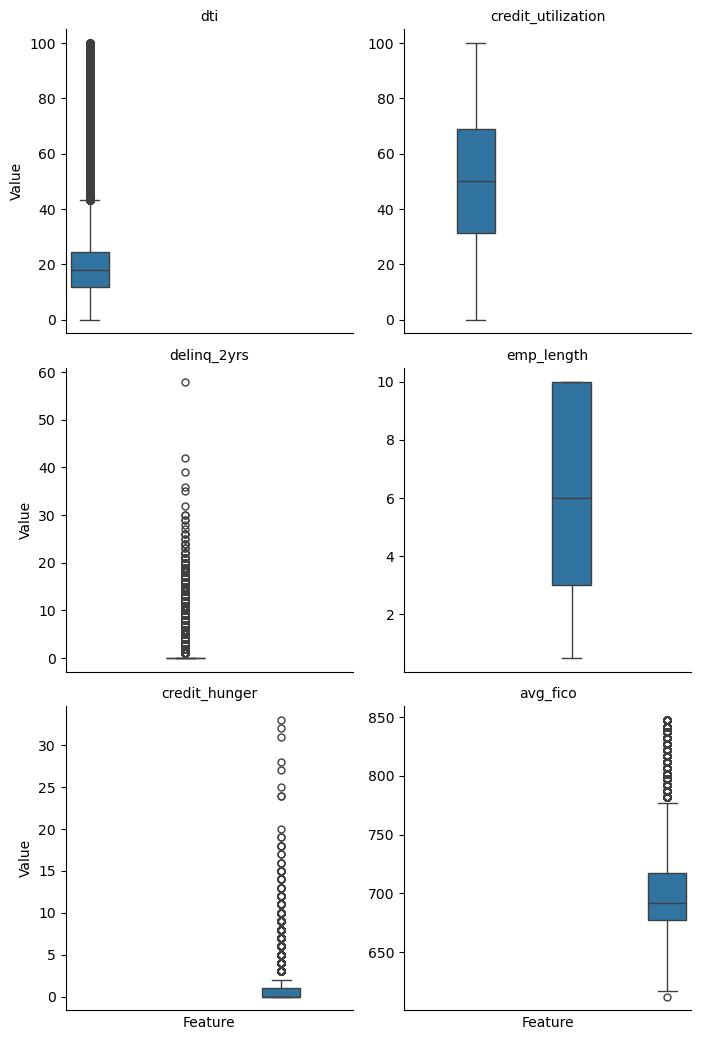

In [19]:
# Outlier detection
for col in features:
    Q1 = credit_data_selected[col].quantile(0.25)
    Q3 = credit_data_selected[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = credit_data_selected[(credit_data_selected[col] < lower) |(credit_data_selected[col] > upper)]
    print(col, ":", len(outliers))
plot_data = credit_data_selected[features].melt(var_name="Feature", value_name="Value")
g = sns.catplot(data=plot_data,x="Feature",y="Value",kind="box",col="Feature",col_wrap=2,sharey=False,height=3.5)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xticks([])
    ax.set_xticklabels([])
plt.tight_layout()
plt.show()

## Outlier Insights

K-Means is sensitive to outliers. The most skewed and outlier-heavy features are:

- `delinq_2yrs`
- `credit_hunger`

These variables are transformed before clustering.

In [20]:
# Skewness before transformation

credit_data_selected[features].skew()

dti                   0.92
credit_utilization   -0.02
delinq_2yrs           5.93
emp_length           -0.17
credit_hunger         2.06
avg_fico              1.19
dtype: float64

## Feature Transformation

Log transformation is applied to highly skewed variables. Original variables are retained for interpretation, while transformed variables are used for clustering.

In [21]:
# Log transformation for highly skewed data

credit_data_selected['credit_hunger'] = np.log1p(credit_data_selected['credit_hunger'])
credit_data_selected['delinq_2yrs'] = np.log1p(credit_data_selected['delinq_2yrs'])

# Skewness after transformation
credit_data_selected[features].skew()


dti                   0.92
credit_utilization   -0.02
delinq_2yrs           2.39
emp_length           -0.17
credit_hunger         0.95
avg_fico              1.19
dtype: float64

## Correlation Analysis

Correlation analysis helps identify relationships and possible redundancy between features. Pairwise correlation is explored on samples due to speed and performance considerations.

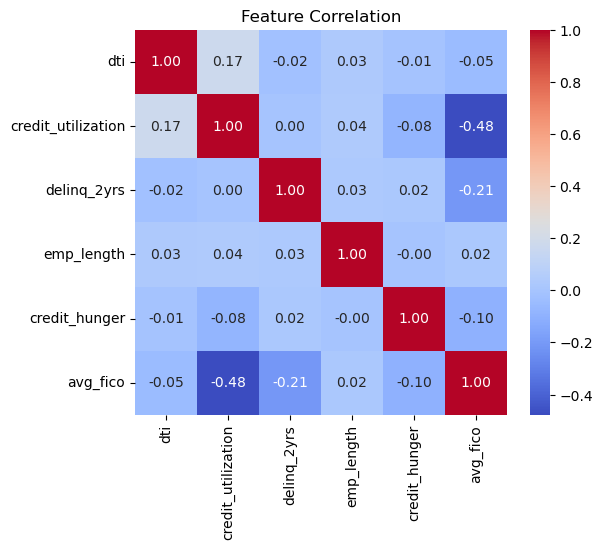

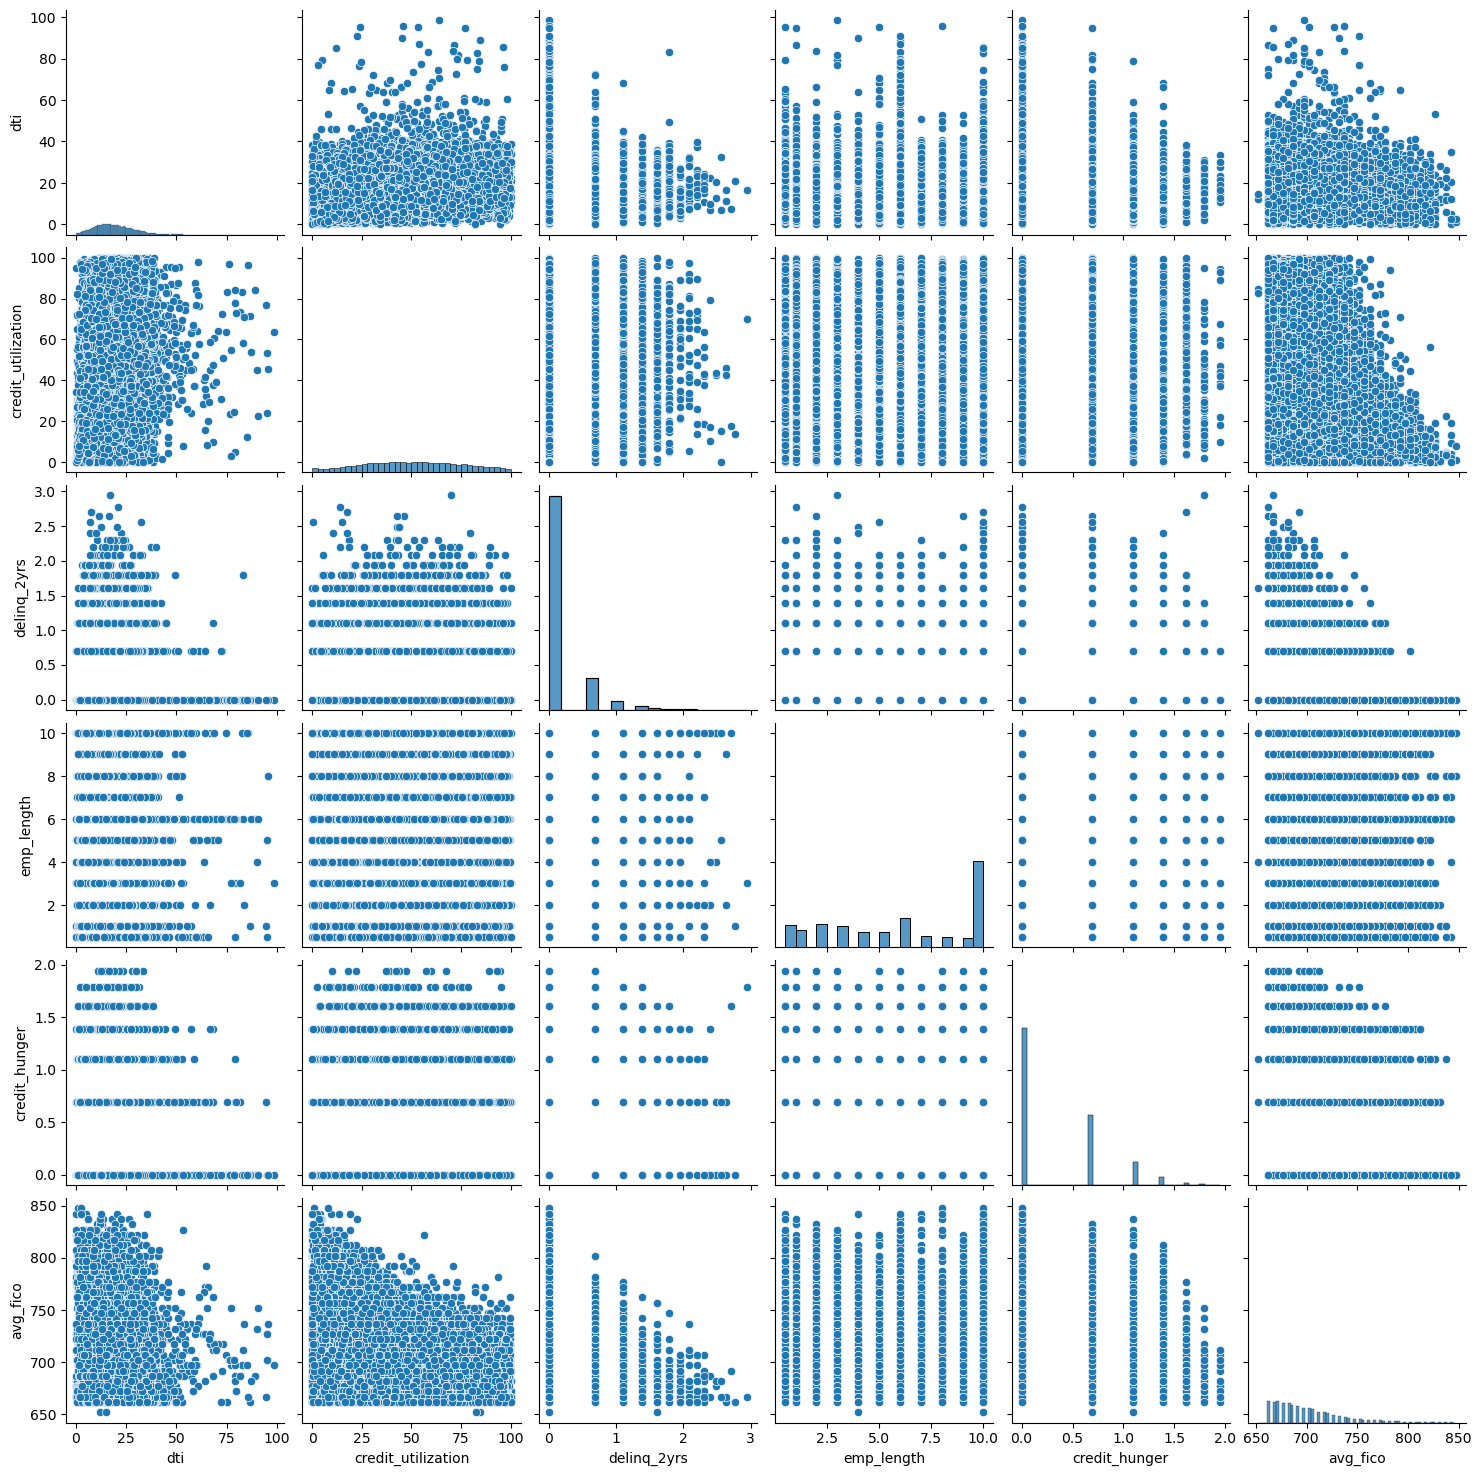

In [22]:
# Correlation heatmap
corr = credit_data_selected[features].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation")
plt.show()

# Pairwise correlation
sample_df = credit_data_selected.sample(20000, random_state=42)
sns.pairplot(sample_df[features])

## Correlation Insights

- FICO has a negative relationship with credit utilisation and delinquency.
- DTI has relatively low correlation with other variables, suggesting it adds independent information.
- The selected features are not excessively redundant.

## Feature Scaling

K-Means is distance-based, so features must be scaled before clustering.

In [23]:
scaler = StandardScaler() 
credit_data_scaled = scaler.fit_transform(credit_data_selected[features])

## Determining the Number of Clusters

The optimal number of clusters is assessed using:

- Elbow Method
- Silhouette Score

The Silhouette Scores are calculated using sampling due to performance considerations.

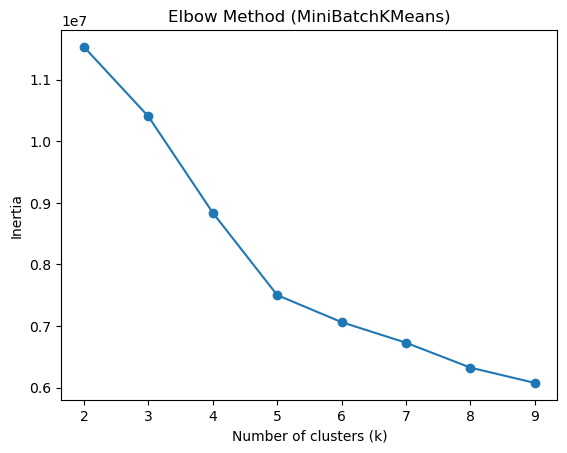

In [24]:
# Elbow Plot
    
inertia = []
k_values = range(2, 10)
for k in k_values:
    mbk = MiniBatchKMeans(n_clusters=k,batch_size=1000,random_state=42)
    mbk.fit(credit_data_scaled)
    inertia.append(mbk.inertia_)
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (MiniBatchKMeans)")
plt.show()


In [25]:
# Silhouette Score

def get_scaled_sample(x):
    sample_indices = np.random.choice(credit_data_scaled.shape[0], x, replace=False)
    return credit_data_scaled[sample_indices]

silhouette_sample_size = 100000
credit_data_sample = get_scaled_sample(silhouette_sample_size)
for k in range(3, 10):
    mbk = MiniBatchKMeans(n_clusters=k, batch_size=1000, random_state=42)
    labels = mbk.fit_predict(credit_data_sample)
    score = silhouette_score(credit_data_sample,labels)
    print(f"k={k}, silhouette score={score:.4f}")

k=3, silhouette score=0.1984


k=4, silhouette score=0.1967


k=5, silhouette score=0.1706


k=6, silhouette score=0.1630


k=7, silhouette score=0.1568


k=8, silhouette score=0.1683


k=9, silhouette score=0.1764


## Cluster Selection

Based on the elbow method and silhouette score, 4 clusters were selected.

The silhouette score indicates moderate separation, which is expected in real-world credit risk data where borrower behaviour exists on a continuum.

## K-Means Clustering

MiniBatch K-Means is used because the dataset is large and contains over 2 million records.

In [26]:
num_clusters = 4
mbk_final = MiniBatchKMeans(n_clusters=num_clusters, batch_size=1000, random_state=42)
credit_data_selected["cluster"] = mbk_final.fit_predict(credit_data_scaled)

## Cluster Summary

Size of clusters and average borrower profile within each cluster are analysed using original, interpretable variables.

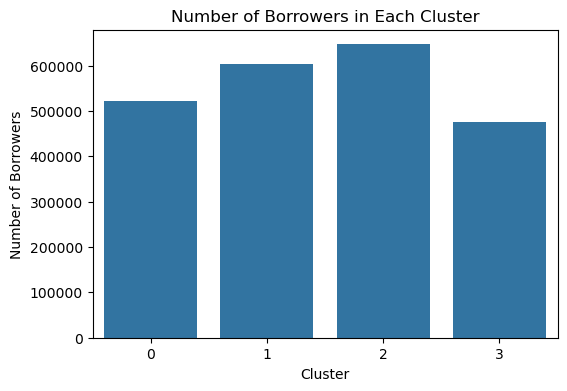

In [27]:
# Cluster size

cluster_size_pct = credit_data_selected["cluster"].value_counts(normalize=True).sort_index() * 100
cluster_size_pct

# Plotting cluster size

plt.figure(figsize=(6, 4))
sns.countplot(data=credit_data_selected,x="cluster",order=sorted(credit_data_selected["cluster"].unique()))
plt.title("Number of Borrowers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Borrowers")
plt.show()

          dti  credit_utilization  delinq_2yrs  emp_length  credit_hunger  \
cluster                                                                     
0       17.46               45.13         0.24        6.59           0.96   
1       20.98               61.91         0.16        2.44           0.17   
2       19.94               63.40         0.19        9.09           0.09   
3       14.89               22.84         0.06        5.56           0.20   

         avg_fico  
cluster            
0          688.52  
1          686.95  
2          690.21  
3          745.28  


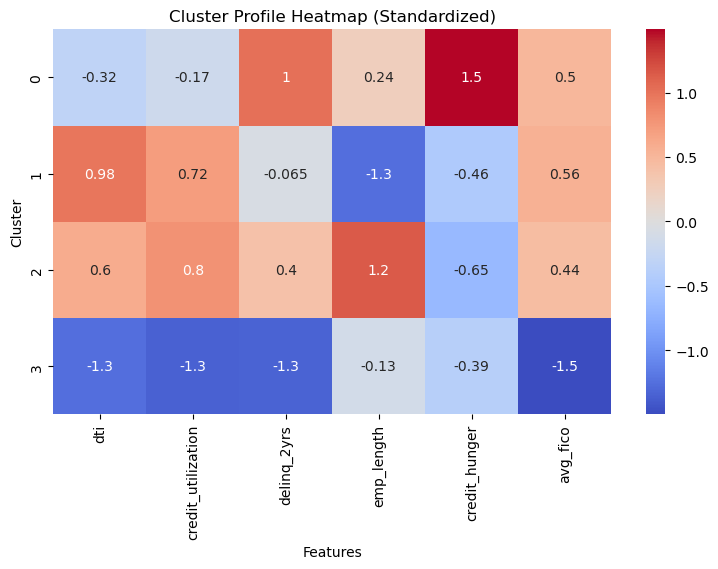

In [29]:
# Cluster summary

cluster_summary = credit_data_selected.groupby("cluster")[features].mean()
print(cluster_summary)

# Cluster Heatmap

credit_data_selected['avg_fico'] = credit_data_selected['avg_fico']*-1
cluster_profile = credit_data_selected.groupby("cluster")[features].mean()
cluster_profile_scaled = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
plt.figure(figsize=(9,5))
sns.heatmap(cluster_profile_scaled,annot=True,cmap="coolwarm",center=0)
plt.title("Cluster Profile Heatmap (Standardized)")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()

## Cluster Interpretation

- Cluster 0 shows weaker repayment behaviour due to higher delinquency and credit activity.
- Cluster 1 reflects borrowers with shorter employment history and higher leverage.
- Cluster 2 represents experienced borrowers with higher credit utilisation.
- Cluster 3 has the strongest credit profile, with high FICO and low risk indicators.

This shows that borrower risk is driven by combinations of features rather than a single variable.

## Cluster Validation using Loan Status

Although clustering is unsupervised, loan status can be used after clustering to assess whether the segments show meaningful differences in borrower performance.

In [31]:
credit_data_selected["cluster"].value_counts()
pd.crosstab(credit_data_selected["cluster"], credit_data_selected["loan_status"], normalize='index')

loan_status,Bad,Delinquent,Good,Ongoing
cluster,,,,
0,0.16,0.02,0.52,0.30
1,0.13,0.02,0.46,0.39
2,0.12,0.01,0.48,0.39
3,0.06,0.01,0.46,0.47


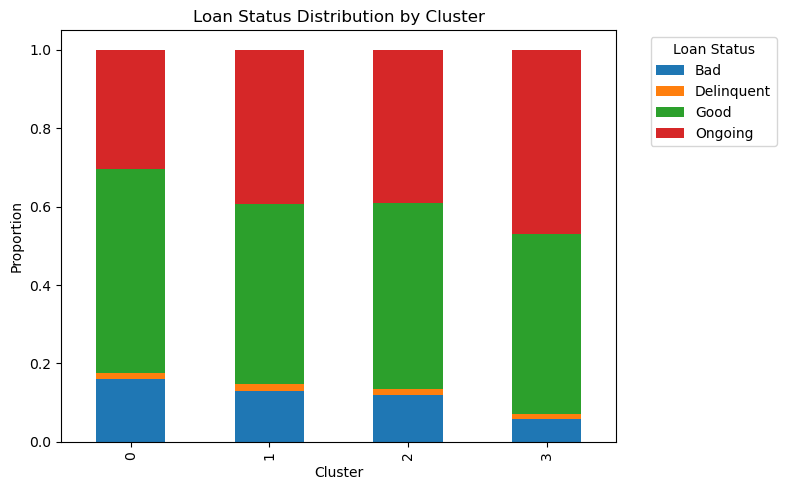

In [32]:
# Loan status distribution plot

cluster_status = pd.crosstab(credit_data_selected["cluster"],credit_data_selected["loan_status"],normalize="index")
cluster_status.plot(kind="bar",stacked=True,figsize=(8, 5))
plt.title("Loan Status Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Validation Insights

The clusters show different loan performance patterns.

- The strongest borrower segment has the lowest bad loan rate.
- Higher-risk clusters show greater delinquency and bad loan proportions.
- This supports the usefulness of clustering for borrower segmentation and portfolio monitoring.

## Final Cluster Labels

Based on the cluster profiles and validation results, the clusters can be labelled as follows:

| Cluster | Segment Name | Description |
|---|---|---|
| 0 | Credit-Stressed / High Activity Borrowers | Higher delinquency and credit activity |
| 1 | Young / Thin Credit Profile Borrowers | Shorter employment history with high leverage |
| 2 | Experienced but Highly Leveraged Borrowers | Longer employment history but high utilisation |
| 3 | Prime / Low-Risk Borrowers | High FICO, low DTI, low utilisation, low delinquency |

In [34]:
# Adding cluster labels

cluster_labels = {
    0: "Credit-Stressed / High Activity",
    1: "Young / Thin Credit Profile",
    2: "Experienced but Highly Leveraged",
    3: "Prime / Low-Risk"
}

credit_data_selected["cluster_label"] = credit_data_selected["cluster"].map(cluster_labels)
pd.DataFrame(list(cluster_labels.items()), columns=["cluster", "cluster_label"])

,cluster,cluster_label
0,0,Credit-Stressed / High Activity
1,1,Young / Thin Credit Profile
2,2,Experienced but Highly Leveraged
3,3,Prime / Low-Risk


## Conclusion

This project demonstrates how unsupervised machine learning can be used to segment borrowers based on credit behaviour.

The analysis identified four distinct borrower groups with different credit risk characteristics. The results show that credit risk is not driven by a single variable, but by combinations of borrower behaviour such as utilisation, delinquency, credit hunger, employment stability, and FICO score.

These borrower segments can support:

- Portfolio monitoring
- Risk-based pricing
- Credit policy design
- Targeted customer strategies